# Brainstorm with ChatGPT

Dynamics on networks can be modelled by means of network automata. We study in particular binary outer-totalistic network automata, i.e. a topological generalisation of life-like cellular automata. Within this model, we will study dynamical perturbations: investigating how small changes to the initial configuration will propagate through the system, potentially affecting the emergent behaviour of the entire system. In particular, we study the relationship between structural properties and dynamical properties, which is to say that we want to find a relationship between node properties and defect propagation. For example, it is to be expected that nodes that are highly connected (with a high degree) will more easily transmit a defect, than nodes that are barely connected (low degree).

**1. What kinds of networks are we considering?**

>We will at first consider lattice graphs that increasingly move towards random graphs by increasing the rewiring probability.

That's a good idea. Note that this will also clearly affect some global network properties, such as average path length. Some suggested metrics are clustering coefficient and defect propagation entropy.

**2. What is the rule space for our binary outer-totalistic automata?**

> The rule space is a generalisation of Life-like cellular automata, called Life-like network automata.

Make sure to relate this to (more recent) papers on "graph cellular automata"

**3. How are we defining a "defect"?**

> A defect is a single toggled node: 0 becomes a 1 or vice versa. It is always applied at time step 0.

Interesting metrics here include (i) defect propagation speed, (ii) time-to-equilibrium, and (iii) perturbation basin (set of nodes eventually affected)

**4. What metrics will we use to quantify the propagation of a defect?**

> We will consider the number of affected nodes over time (that's the most straightforward), but we could also consider the defect entropy or the Lyapunov exponent. As long as it can be related to the perturbation in a single node.

We should define a Lyapunov exponent for each node (only flipping that node, and averaging over various initial configurations). ChatGPT suggests working with the Jensen-Shannon divergence. 

**5. How will we relate node properties to defect propagation?**

> We prefer simple and interpretable properties on the node level, and also prefer properties that are unique and impose a clear order (like Pagerank).

PageRank accounts for both degree and position in the network, so this makes sense. We should definitely compare PageRank, degree, closeness, betweenness, and k-core index. Centrality refers to a measure that assigns importance or influence to nodes. We could define a new concept which we may call "defect centrality", which is a dynamical counterpart of the structural centrality measures.

Important: a very influential work is called "Identification of influential spreaders in complex networks" (in Nature).

**6. Are the network topologies static or dynamic?**

> The topologies are static.

We could further identify some global network measures (even though they do not say something about the node level).

**7. How will we sample or generate initial configurations?**

> We will start with a random initial state with a fixed overall density (so exactly half of the nodes are in one state, and the other half in the other).

It is definitely interesting to compare random vs. structured seeds, e.g. seeds in which nodes in the same community start off with the same initial configuration.

**8. What role does stochasticity play in our model, if any?**

> The dynamics are purely deterministic.

This guarantees that all observed randomness coems from the structure and the initial configuration, which is easier in terms of analysis. We should use a bifurcation diagram to show phase transitions.

**9. What kinds of emergent behaviour are we hoping to identify or characterise?**

> We hope to identify the node property that has the highest predictive value for defect propagation. In other words, we want to find the node that has the highest impact on the emergent dynamical behaviour.

**10. Do we envision potential applications or analogies in real-world systems?**

> The clearest example is social contagion: opinion spread models. This may address for example the question "which community should I target in order to affect the election outcome?"



# Additional ideas and remarks

1. The standard idea is to introduce defects based on the structural node properties. However, defects may also be introduced based on the properties of the initial configuration. For example, if the initial configuration generates a locally highly dense region (a clique in which all nodes have the same state), it may be interesting to target the central node specifically _in this clique_. This is what I mean with a dynamically inspired targeted defect: it depends on the states, not (only) on the structure. This is known as "structural targeting" versus "contextual targeting"

2. Instead of using the Lyapunov exponent (which does not make a whole lot of sense for our purpose), we could trace (i) the defect size over time, (ii) the cumulative defect over time, or (iii) the defect trace entropy. This would depend on the node that was originally perturbed.

3. Like in the Nature Physics paper, we could consider the $k$-shell decomposition of the network, and consider the influence of nodes based on this distinction. In `igraph` this is the `coreness()` method. The $k$-shell decomposition is not really useful when considering random networks or small-world networks, as most of the nodes will have large coreness (there is no real distinction). Mental note: think about "pruning" the network.

4. Important difference with the Nature Physics paper is that we will mostly consider damage spread, not state spread (although both would probably be interesting). Importantly, they only study the SIS and SIR model. Our model is much more general.

5. Particular network types have a small core. Random graphs and small-world graphs certainly do _not_ have a small core. Scale-free networks and tree/hierarchy networks also not really. Networks can be made especially for this purpose: core-periphery networks. In these networks, the core is strongly connected with itself.

6. The betweenness measure appears to be a bad predictor of viral spread! That's new. Also the node degree is not a great predictor, and there is a strong correlation between node degree and PageRank. Also the Nature paper says that a high node degree is not a property that the "driver nodes" necessarily have.

7. It appears that the $k$-shell strategy is only relevant when multiple seeds are chosen (over 2 percent of all nodes). Otherwise, the degree is an equally good predictor.

8. Another interesting metric to study is the **persistence**, which is the probability (over time) that a particular node becomes infected. And the imprecision function may be useful to check how good a structural property is at predicting certain dynamical behaviour.

9. Erkol et al. (2019) made a big comparison of many properties and how they are correlated with spreading on networks. They find that simple metrics like adaptive degree and closeness centrality can already tell us a lot about the potential for spreading. Does this contradict the paper in Nature Physics?

10. Definitely interesting is the Gates and Rocha paper from 2016, where they highlight that dynamical properties are also important for controlling complex networks (not just structure).

11. We could just work with threshold rules, but these do not lead to the same outcome as the annealed rule. The annealed rule has some de facto randomness around the edge, which 'shakes up' the system, which makes sure that we obtain large patches of identical states.

# Possible research questions

1. Following the Nature Physics paper: is the $k$-shell measure also a robust indicator for the spreading efficiency for all non-equivalent LLNAs
    - We would need to study this in networks that have a variety of $k_s$ values, that ideally do not correlate too much with the degree $k$.
    - Make a clear distinction between seeding (as is done in the paper) and damaging (which is not treated). Note that the SIS model will always allow some spreading, while a number of LLNA rules will just always die out immediately.
    - Note that the situation is quite different when we impose multiple seeds at the same time

2. Establish a link between Extreme Learning Machines and influence maximisation in Network Automata. There might be something there.

3. Instead of changing a node's value in the very start, and then having it run along, we could also experiment with "pinning control", which means that a node's value is fixed over time. This represents for example a political agent whose opinion cannot be changed under any circumstances, and which may be mobilised to target a particular community. There is a whole literature around this (see refs. in Parmer 2022). I could then use the algorithm that is proposed in that work, to look for the set of nodes that are the most influential on dynamical grounds.

4. As is mentioned in Parmer 2022 in the end: "our definition of dynamical influence and our algorithm for the selection of optimal driver sets can be extended to study the effect of short-term perturbations, i.e., the state of the seeds is only initially set to a given value but can be altered by the dynamics of the network."

5. I could check all rules that are equivalent to themselves only (cause that's a constraint). There are really not that many, only $2^r$ with $r$ the resolution, i.e. only $512$ of the $262144$ rules for resolution $9$. That's workable.

6. The inverse question is also interesting: which are the nodes that are not important at all? For which the value does not matter?

7. Rather than pushing in a single direction, we would want to find methods to de-polarise. There are also a lot of LLNAs like that: those that allow for a co-existence, and an extreme position.

8. What is the big difference between $\phi^9_{488,464}$ and $\phi^9_{464,488}$? They are so similar, yet on a small-world network, one will almost always move towards a totalitarian regime, while the other moves towards a frozen regime.

In [2]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

# The Anneal Life-like CA/NA

## Inspect the update diagram

This rule is equivalent to itself.


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{464,488}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

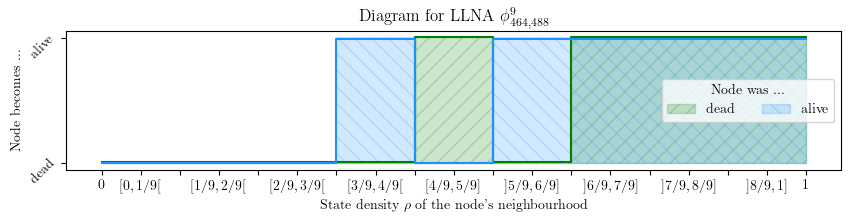

In [4]:
life_like_dict = return_life_like_dict()
life_like_name = 'anneal'

resolution = 9
beta, sigma = life_like_dict[life_like_name]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

Note that this is kind of like a threshold rule, but with some 'unexpected behaviour' around the centre density values.

## Inspect the mean-field curve and the Derrida curve

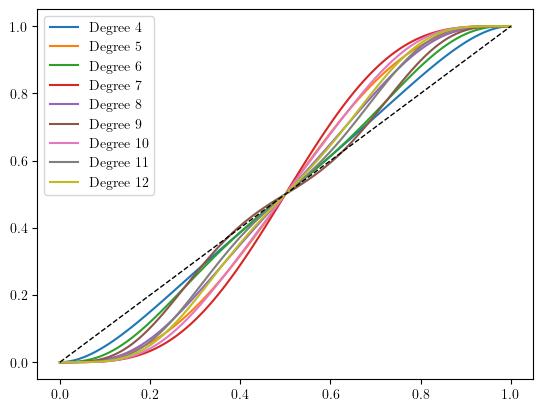

In [5]:
rho0_array = np.linspace(0,1,101)
degrees= np.arange(4,13,1, dtype=int)
rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])

for degree, rho1_array in zip(degrees, rho1_arrays):
    plt.plot(rho0_array, rho1_array, label=f"Degree {degree}")
plt.plot([0,1], [0,1], lw=1, ls='--', color='k')
plt.legend()

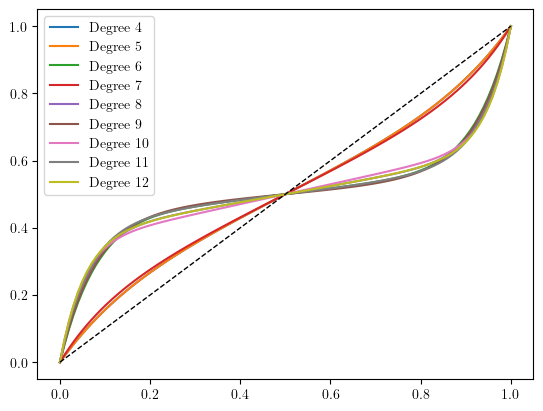

In [6]:
degrees= np.arange(4,13,1, dtype=int)
delta0_array = np.linspace(0,1,101)
delta1_arrays = np.array([derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree, init_config_dens=0.5) for degree in degrees])

for degree, delta1_array in zip(degrees, delta1_arrays):
    plt.plot(delta0_array, delta1_array, label=f"Degree {degree}")
plt.plot([0,1], [0,1], lw=1, ls='--', color='k')
plt.legend()

Note that the mean-field curve displays a unstable equilibrium at $\rho^0=1/2$, and that the Boolean sensitivity is really high. That's what we want. Let's search over all self-equivalent rules of resolution $9$ and look for all rules with a Hamming weight of 0.5 (such that it's an equilibrium). Later we can filter further, demanding that the equilibrium is unstable, and that the associated Boolean sensitivity must be high (which is probably related).

In [7]:
# watch out! takes about ten minutes for resolution 9
# resolution = 9
# nonequiv_rule_list, self_equiv_rule_list = get_nonequiv_rules(9, return_self_equiv=True)

# np.save(nonequiv_rule_list_name, nonequiv_rule_list)
# np.save(self_equiv_rule_list_name, self_equiv_rule_list)

nonequiv_rule_list_name = f"all_nonequiv_res{resolution}_rules.npy"
self_equiv_rule_list_name = f"all_self_equiv_res{resolution}_rules.npy"

nonequiv_rule_list = np.load(nonequiv_rule_list_name)
self_equiv_rule_list = np.load(self_equiv_rule_list_name)

An additional demand is that the final state won't be an infinite oscillation. That can be found by demanding that a dead cell remains dead if it is surrounded by only dead cells. In other words, if $R_0 \not\in B$. Because the rule is self-equivalent, this automatically entails that $R_k \in S$, so living cells do not spontaneously die when surrounded by other living cells. Therefore, this demand cuts the number of possible rules in half. Let's call these rules the legal self-equivalent rules.

In [8]:
legal_self_equiv_rule_list = []
for beta, sigma in self_equiv_rule_list:
    if beta%2 == 0:
        legal_self_equiv_rule_list.append((beta, sigma))

len(legal_self_equiv_rule_list)

256

### Slope of the mean field curve

Now we only want to keep those rules that have an unstable equilibrium, so for which the slope at the equilibrium is larger than $1$.

If the HW is 0.5, I think the slope of the tangent through that equilibrium at $\rho = 1/2$ for degree $k$ should be
$$
\left.\frac{d\rho^1}{d\rho^0}\right|_{\rho=1/2} = \sum_{s\in\{0,1\}} \sum_{q=0}^k \binom{k}{q} \rho^k(2s + 2q - k - 1) \phi(s, q/k)
$$
which can easily be calculated for any local update rule.

More generally, the slope through the mean field curve at $\rho^0 = \rho$ is
$$
\left.\frac{d\rho^1}{d\rho^0}\right|_{\rho} = \sum_{s\in\{0,1\}} \sum_{q=0}^k \binom{k}{q} (\rho)^{s+q-1} (1-\rho)^{k-s-q}[s+q-\rho(1+k)] \phi(s, q/k)
$$

### Slope of the Derrida curve

The Boolean sensitivity is the slope of the tangent to the Derrida curve at the origin when the average density is 0.5. This can be generalised to the slope anywhere on the Derrida curve, and to any average density.
For a density $\rho$ and a particular degree $k$ we find that the slope through the origin is
$$
\left.\frac{d\delta^1}{d\delta^0}\right|_{\delta^0=0} = \sum_{s\in\{0,1\}} \sum_{q=0}^k \binom{k}{q} \rho^{q+s} (1-\rho)^{1-s+k-q}\Big( \text{IS}(s,q,k) + \text{NS}(s,q,k) \Big)
$$
The slope of the tangent through the Derrida curve for any value of $\delta^0$ is
$$
\left.\frac{d\delta^1}{d\delta^0}\right|_{\delta^0=\delta} =
            \sum_{s \in \{0,1\}}
            \sum_{q=0}^k \binom{k}{q} \rho^{q+s} (1-\rho)^{1-s+k-q}
            \sum_{c \in \{0,1\}}
            \sum_{d=0}^k \binom{k}{d} (\delta)^{c+d-1} (1-\delta)^{k-c-d}[c+d-\delta(1+k)]
            \sum_{t} \binom{q}{t}\binom{k-q}{d-t} \bigg/ \binom{k}{d}
            \Bigg[\phi\bigg(s, \frac{q}{k}\bigg) \oplus \phi\bigg(s\oplus c, \frac{q-2t+d}{k}\bigg)\Bigg].
$$
But we won't directly use the general formula for the slope. We are mainly interested in what happens for tiny perturbations.

Text(0.5, 1.0, '$\\beta = 390$, $\\sigma = 316$')

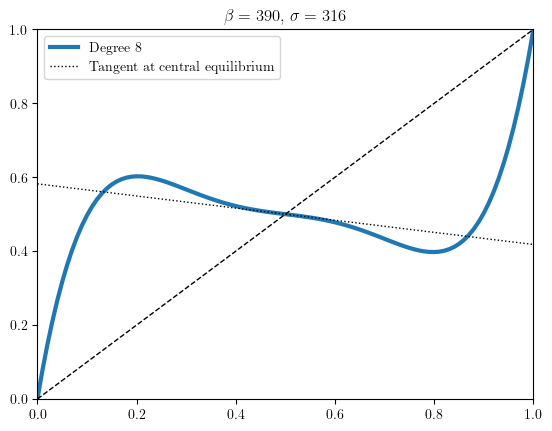

In [11]:
beta, sigma = legal_self_equiv_rule_list[np.random.randint(len(legal_self_equiv_rule_list))]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)

rho_star = 0.5
slope = mean_field_slope(resolution, B_set, S_set, degree, rho_star=rho_star)
intercept = 0.5*(1-slope)

plt.plot(rho0_array, rho1_array, label=f"Degree {degree}", lw=3)
plt.plot([0,1], [0,1], lw=1, ls='--', color='k')
plt.plot([0, 1], [intercept, slope+intercept], lw=1, ls=':', color='k', label="Tangent at central equilibrium")
plt.legend()

plt.xlim([0,1])
plt.ylim([0,1])

plt.title(f"$\\beta = {beta}$, $\\sigma = {sigma}$")

In [12]:
# note: if slope >= 1, we find 49 rules;
# if slope > 1, we find 46 rules. (so it's equal for three rules, and these are not necessarily unstable)

unstable_legal_self_equiv_rule_list = []
for beta, sigma in legal_self_equiv_rule_list:
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    rho_star = 0.5
    slope = mean_field_slope(resolution, B_set, S_set, degree, rho_star=rho_star)
    if slope >= 1:
        unstable_legal_self_equiv_rule_list.append((beta, sigma))

len(unstable_legal_self_equiv_rule_list)

49

Text(0.5, 1.0, '$\\beta = 354$, $\\sigma = 370$')

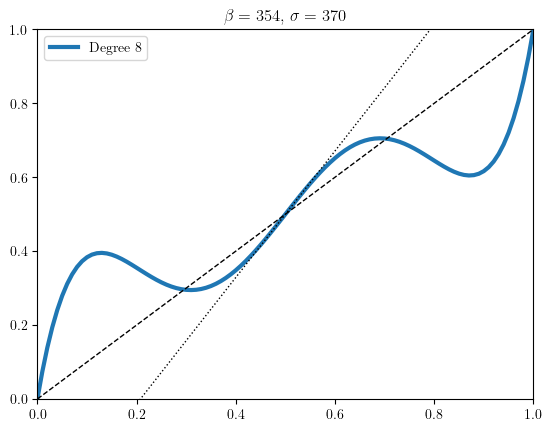

In [19]:
beta, sigma = unstable_legal_self_equiv_rule_list[np.random.randint(len(unstable_legal_self_equiv_rule_list))]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)

rho_star = 0.5
slope = mean_field_slope(resolution, B_set, S_set, degree, rho_star=rho_star)
intercept = 0.5*(1-slope)

plt.plot(rho0_array, rho1_array, label=f"Degree {degree}", lw=3)
plt.plot([0,1], [0,1], lw=1, ls='--', color='k')
plt.plot([0, 1], [intercept, slope+intercept], lw=1, ls=':', color='k')
plt.legend()

plt.xlim([0,1])
plt.ylim([0,1])

plt.title(f"$\\beta = {beta}$, $\\sigma = {sigma}$")

Quick look at what happens if we follow the update logic of the mean field curve, towards or away from the equilibria

Text(0.5, 1.0, '$\\beta = 354$, $\\sigma = 370$')

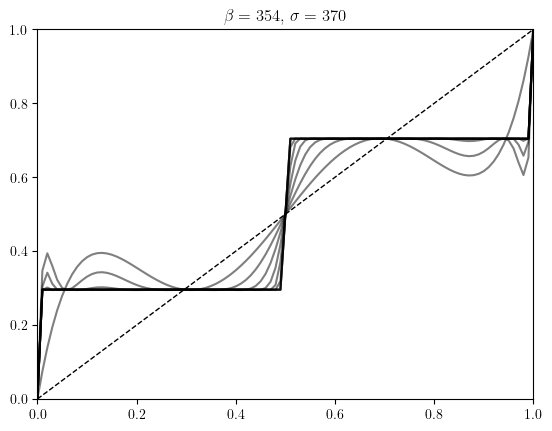

In [20]:
rho0_array = np.linspace(0,1,101)
degree = 8
T = 10

rhot_array = rho0_array.copy()
for t in range(T):
    rhot_array = mean_field_dens_propagation(resolution, B_set, S_set, rhot_array, degree)
    plt.plot(rho0_array, rhot_array, color='k', alpha=0.5)

plt.plot([0,1], [0,1], lw=1, ls='--', color='k')

plt.xlim([0,1])
plt.ylim([0,1])

plt.title(f"$\\beta = {beta}$, $\\sigma = {sigma}$")

Ok, not that many left now! These remaining ones we want to order based on the Boolean sensitivity. I'm curious whether there is a link between both, now.

100%|██████████| 49/49 [00:00<00:00, 595.68it/s]


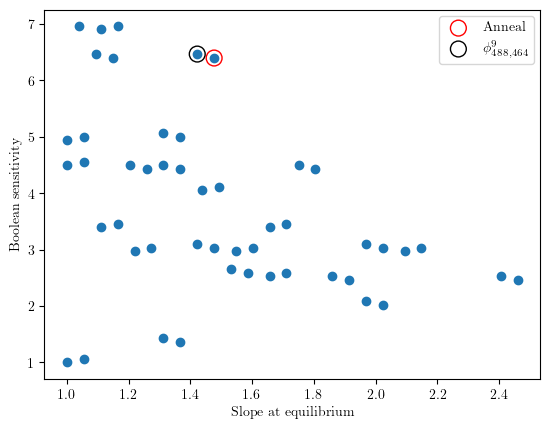

In [21]:
bs_list = []
slope_list = []
degree = 8
for (beta, sigma) in tqdm(unstable_legal_self_equiv_rule_list, total=len(unstable_legal_self_equiv_rule_list)):
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    bs = boolean_sens(resolution, B_set, S_set, degree)
    slope = mean_field_slope(resolution, B_set, S_set, degree)
    bs_list.append(bs)
    slope_list.append(slope)

plt.scatter(slope_list, bs_list)
plt.xlabel(f"Slope at equilibrium")
plt.ylabel(f"Boolean sensitivity")

# show where Anneal is
beta, sigma = life_like_dict["anneal"]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
bs_anneal = boolean_sens(resolution, B_set, S_set, degree)
slope_anneal = mean_field_slope(resolution, B_set, S_set, degree)
plt.scatter(slope_anneal, bs_anneal, marker='o', s=130, facecolors='none', color='red', label="Anneal")

# show where (488,464) is
beta, sigma = (208, 489)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
bs_488 = boolean_sens(resolution, B_set, S_set, degree)
slope_488 = mean_field_slope(resolution, B_set, S_set, degree)
plt.scatter(slope_488, bs_488, marker='o', s=130, facecolors='none', color='black', label="$\\phi^9_{488,464}$")

plt.legend()

# NOTE: the Day & Night rule does not qualify! because it is an equilibrium.

# beta, sigma = life_like_dict["day&night"]
# B_set = binary_indices(beta)
# S_set = binary_indices(sigma)
# bs_dan = boolean_sens(resolution, B_set, S_set, degree)
# slope_dan = slope_at_equilibrium(resolution, B_set, S_set, degree)
# plt.scatter(slope_dan, bs_dan, marker='*', color='green', label="Day & Night")

Note that all Boolean sensitivity values are larger than or equal to $1$. Now, the thing is that we want to have a rule that is eager to move away from an equilibrium, and that is a the same time very sensitive to initial changes in its initial configuration. Looks like we're going to have to do some kind of a trade-off here. But let's first look at the extremes. First the rule with the maximal slope.

Note that in the figure above, we are only interested in the top right ruels. All other rules (that are not on the edge) have fitter alternatives, presumably. We did not check this, though, and it would certainly be possible to just run over all these rules here.

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{480,496}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

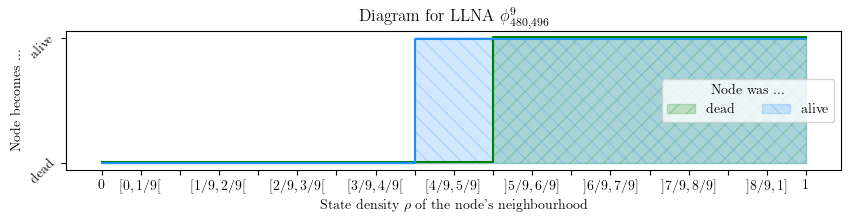

In [22]:
beta_max_slope, sigma_max_slope = unstable_legal_self_equiv_rule_list[np.argmax(slope_list)]
B_set = binary_indices(beta_max_slope)
S_set = binary_indices(sigma_max_slope)
model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

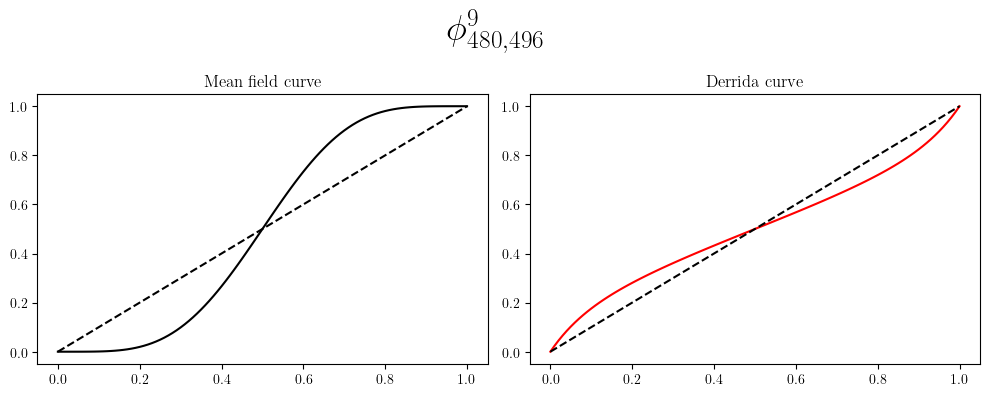

In [23]:
fig, axs = plt.subplots(1,2,figsize=(10,4))

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)
axs[0].plot(rho0_array, rho1_array, color='k')
axs[0].plot([0,1], [0,1], 'k--')
axs[0].set_title(f"Mean field curve")

delta0_array = np.linspace(0,1,101)
delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
axs[1].plot(delta0_array, delta1_array, color='red')
axs[1].plot([0,1], [0,1], 'k--')
axs[1].set_title(f"Derrida curve")

fig.suptitle(f"{model.__str__(latex=True)}", fontsize=26)
plt.tight_layout()

We find rule $\phi^9_{480,496}$. As expected, this is just the threshold rule. In practice, this is not a very good majority rule, though. Now the rule with the maximal Boolean sensitivity.

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{336,490}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

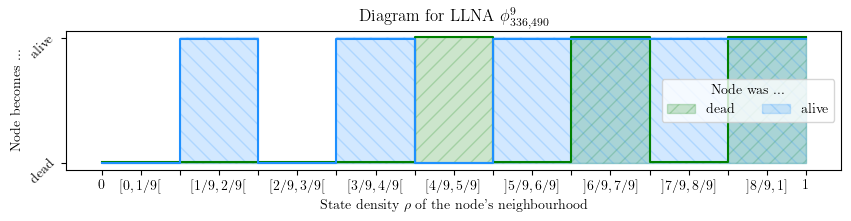

In [24]:
beta_max_bs, sigma_max_bs = unstable_legal_self_equiv_rule_list[np.argmax(bs_list)]
B_set = binary_indices(beta_max_bs)
S_set = binary_indices(sigma_max_bs)
model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

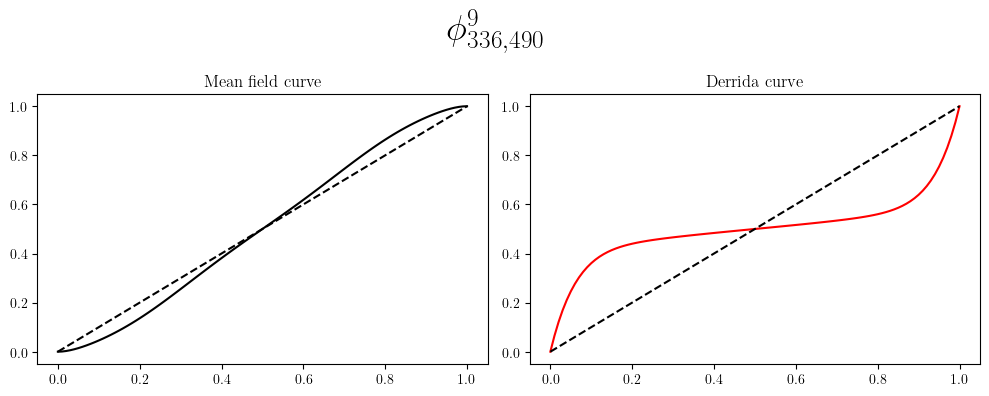

In [25]:
fig, axs = plt.subplots(1,2,figsize=(10,4))

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)
axs[0].plot(rho0_array, rho1_array, color='k')
axs[0].plot([0,1], [0,1], 'k--')
axs[0].set_title(f"Mean field curve")

delta0_array = np.linspace(0,1,101)
delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
axs[1].plot(delta0_array, delta1_array, color='red')
axs[1].plot([0,1], [0,1], 'k--')
axs[1].set_title(f"Derrida curve")

fig.suptitle(f"{model.__str__(latex=True)}", fontsize=26)
plt.tight_layout()

This is quite interesting! We find rule $\phi^9_{336,490}$. But probably the one in the middle region will be most useful. Visually, it looks like we'd be happy with those two rules with a slope larger than 1.6 and a BS larger than 4.

NOTE: in the mean time, we found that it appears that Derrida coefficient is more important than the slope. That probably means that local structure can cause the system to get stuck, also if the slope is large, and we need a consideral BS in order to get 'rattled' out of this impasse.

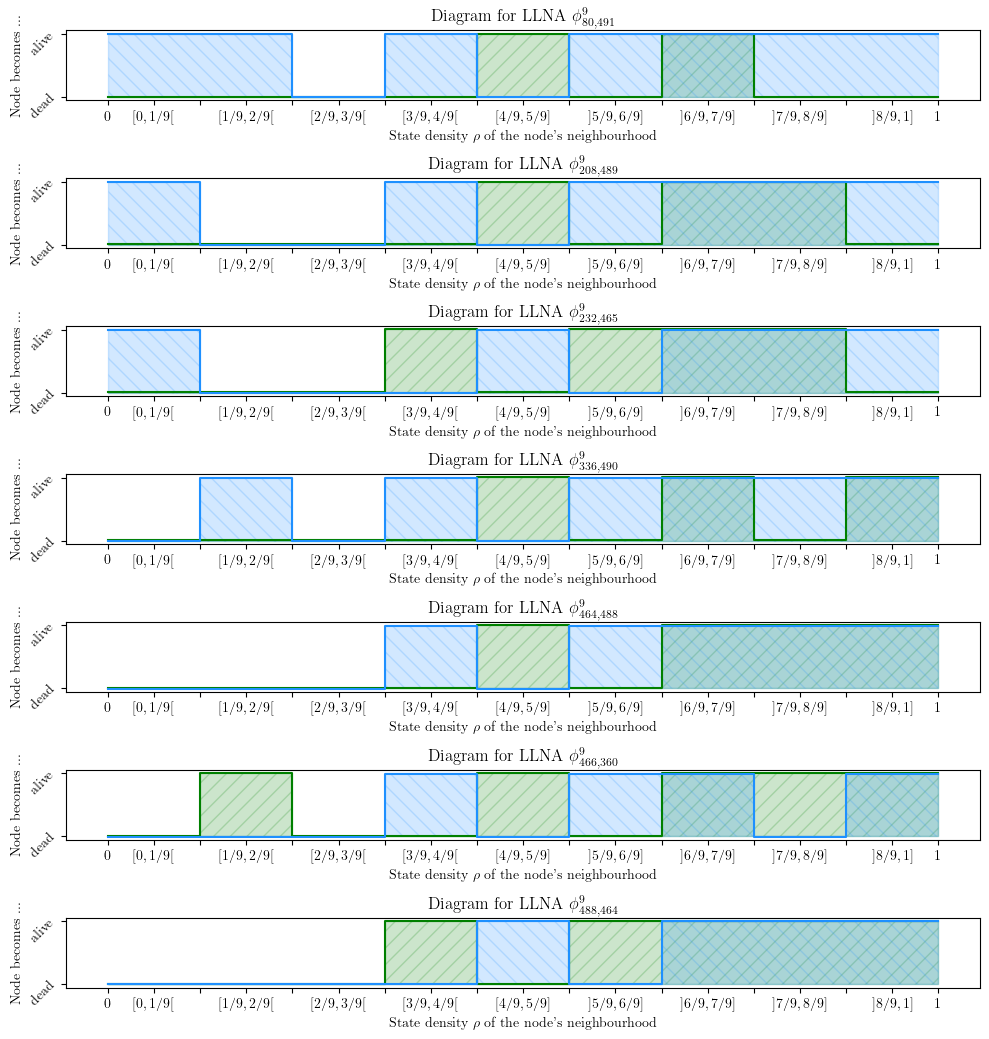

In [26]:
bs_array = np.array(bs_list)
slope_array = np.array(slope_list)
unstable_legal_self_equiv_rule_array = np.array(unstable_legal_self_equiv_rule_list)

bs_cutoff = 6
slope_cutoff = 1
candidate_rules = unstable_legal_self_equiv_rule_array[(bs_array>bs_cutoff) & (slope_array>slope_cutoff)]

fig, axs = plt.subplots(candidate_rules.shape[0],1,figsize=(10,1.5*candidate_rules.shape[0]))

for ax, candidate_rule in zip(axs, candidate_rules):
    beta, sigma = candidate_rule
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    model = LLNA(resolution, B_set, S_set, iso=True)
    model.diagram(ax=ax)
    ax.legend().set_visible(False)

plt.tight_layout()

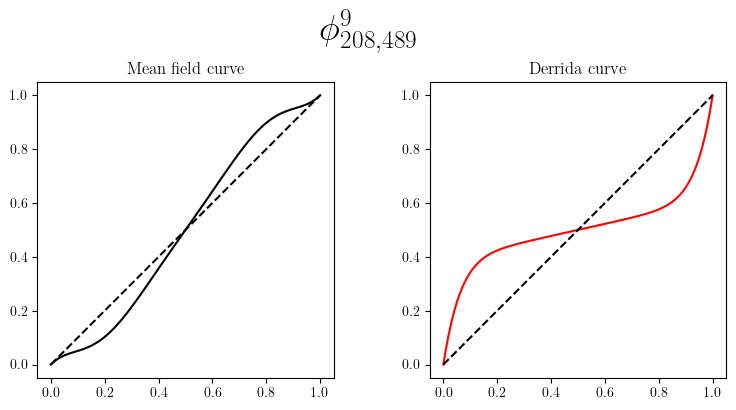

In [27]:
fig, axs = plt.subplots(1,2,figsize=(8,4))

beta, sigma = candidate_rules[1]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram(ax=ax)

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)
axs[0].plot(rho0_array, rho1_array, color='k')
axs[0].plot([0,1], [0,1], 'k--')
axs[0].set_title(f"Mean field curve")

delta0_array = np.linspace(0,1,101)
delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
axs[1].plot(delta0_array, delta1_array, color='red')
axs[1].plot([0,1], [0,1], 'k--')
axs[1].set_title(f"Derrida curve")

for ax in axs: ax.set_aspect(1)

fig.suptitle(f"{model.__str__(latex=True)}", fontsize=26)
plt.tight_layout()

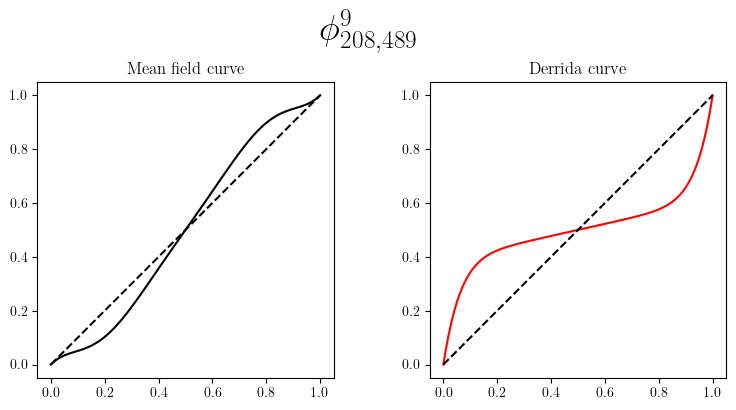

In [28]:
fig, axs = plt.subplots(1,2,figsize=(8,4))

beta, sigma = candidate_rules[1]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram(ax=ax)

rho0_array = np.linspace(0,1,101)
degree = 8
rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)
axs[0].plot(rho0_array, rho1_array, color='k')
axs[0].plot([0,1], [0,1], 'k--')
axs[0].set_title(f"Mean field curve")

delta0_array = np.linspace(0,1,101)
delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
axs[1].plot(delta0_array, delta1_array, color='r')
axs[1].plot([0,1], [0,1], 'k--')
axs[1].set_title(f"Derrida curve")

for ax in axs: ax.set_aspect(1)

fig.suptitle(f"{model.__str__(latex=True)}", fontsize=26)
plt.tight_layout()

## inspect all 49 rules that have made the cut

100%|██████████| 7/7 [00:14<00:00,  2.04s/it]


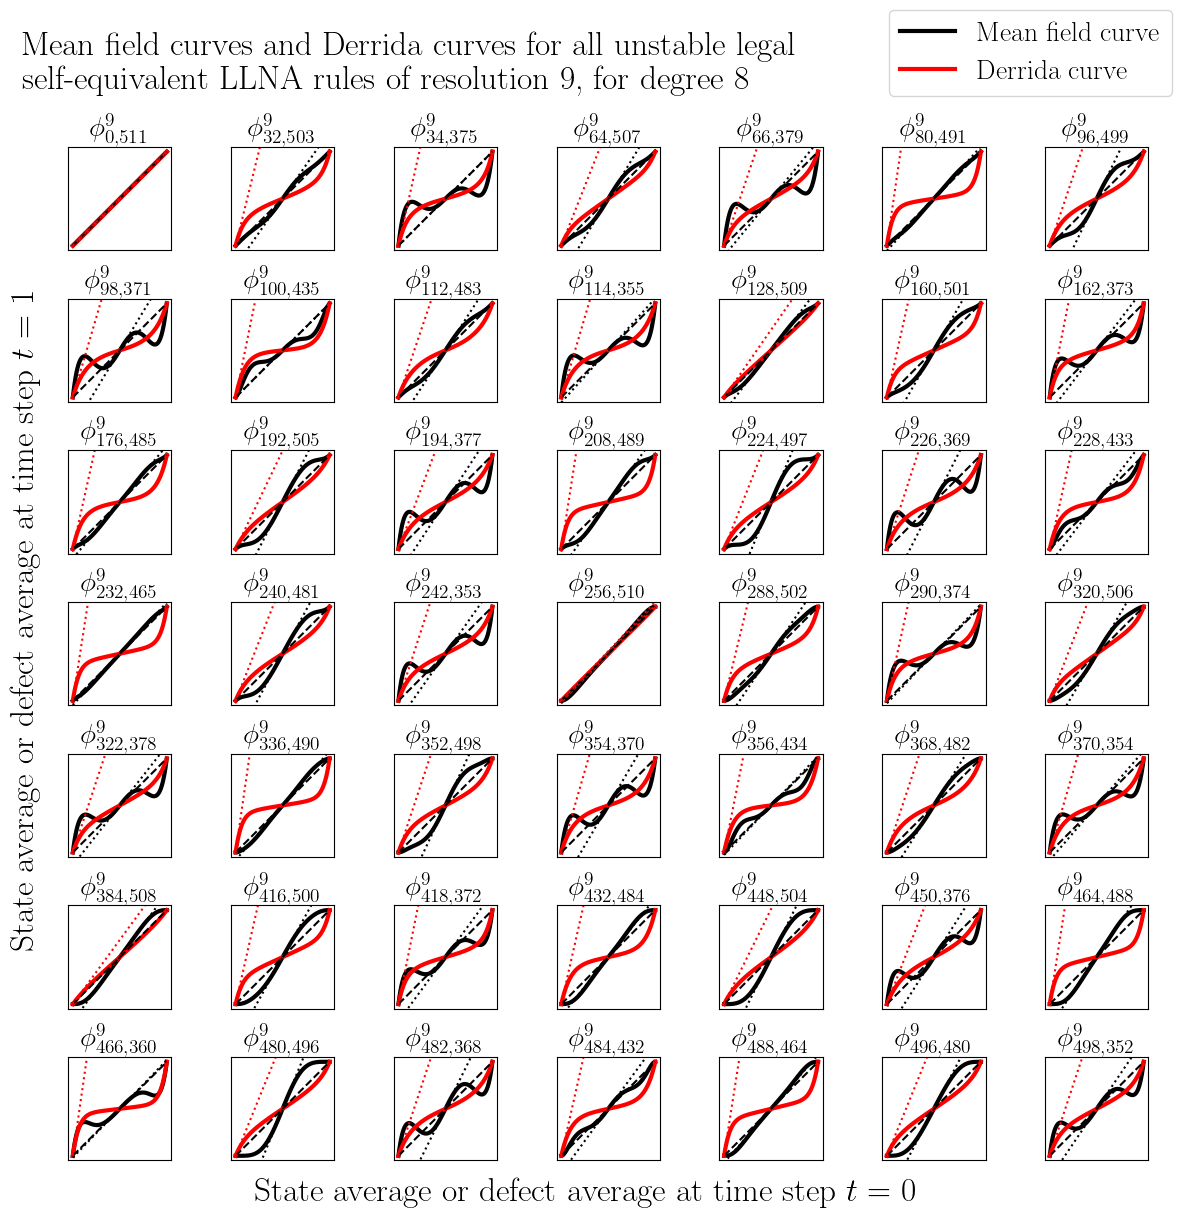

In [ ]:
SAVEFIG=True

fig, axs = plt.subplots(7,7,figsize=(12,12))
resolution = 9
degree = 8

curve_res = 101
rho0_array = np.linspace(0,1,curve_res)
delta0_array = np.linspace(0,1,curve_res)

for row, ax_row in tqdm(enumerate(axs), total=axs.shape[0]):
    for col, ax in enumerate(ax_row):
        # find rule for this particular ax
        idx = row*7 + col
        beta, sigma = unstable_legal_self_equiv_rule_array[idx]
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        # calculate mean field curves and Derrida curves
        rho1_array = mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree)
        delta1_array = derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree)
        # make plot
        ax.plot(rho0_array, rho1_array, color='black', label="Mean field curve", lw=3)
        ax.plot(delta0_array, delta1_array, color='red', label="Derrida curve", lw=3)
        ax.plot([0,1], [0,1], 'k--')
        ax.set_title(f"$\\phi^{resolution}_{{{beta},{sigma}}}$", fontsize=20)
        # make tangent lines
        slope = mean_field_slope(resolution, B_set, S_set, degree, rho_star=0.5)
        intercept = 0.5*(1-slope)
        ax.plot([0,1], [intercept, slope+intercept], 'k:')
        ax.plot([0,1], [0, boolean_sens(resolution, B_set, S_set, degree)], 'r:')
        # make plots nicer
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect(1)

fontsize=24
fig.supxlabel(f"State average or defect average at time step $t=0$", fontsize=fontsize)
fig.supylabel(f"State average or defect average at time step $t=1$", fontsize=fontsize)
fig.suptitle(f"Mean field curves and Derrida curves for all unstable legal\nself-equivalent LLNA rules of resolution {resolution}, for degree {degree}", fontsize=fontsize, x=0.03, y=0.99, ha='left')
fig.legend(['Mean field curve', 'Derrida curve'], loc='upper right', bbox_to_anchor=(1,1.02), ncol=1, fontsize=20)
fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"mean-field-and-derrida-for-all-res9-unstable-legal-self-equiv-llnas_degree8.pdf")

We see that many rules have multiple equilibria: the centre one is unstable (by construction), and the other ones are stable, such that the system evolves towards this unequal stable final situation.

Next, we could do the following
- Calculate the plot above for a spread of values associated with various degrees.
    - What shape of the curves are we most interested in? Mean field curve should probably always be on the same side of the curve
    - It may be interesting if the BS is quite spread out, because this means it is more useful to distinguish between nodes that can be targeted.
- Do something similar for resolution 7, 5, and 3. Perhaps the performance is identical? I don't thing so, though, cause it appears that the Boolean sensitivity is quite important.
- Look at time series for all of these
    - For lattice, small world, and random graph
    - It should always end up on either side of the density. We can calculate the spread of this final result.
    - We can also calculate the expected value from mean field theory (by iterating the mean field curve)
- Make a plot that answers the question: "how many nodes should we flip to get to the other side?".
    - Always start with the same initial configuration
    - Start flipping nodes. For the lattice, there is no structural information, but we could look at nodes with a particular neighbourhood
    - For networks

## Same curve, for spread of degrees

Working on row 0 ...


100%|██████████| 7/7 [00:15<00:00,  2.22s/it]


Working on row 1 ...


100%|██████████| 7/7 [00:16<00:00,  2.31s/it]


Working on row 2 ...


...

100%|██████████| 7/7 [00:16<00:00,  2.33s/it]


Working on row 5 ...


100%|██████████| 7/7 [00:16<00:00,  2.38s/it]


Working on row 6 ...


100%|██████████| 7/7 [00:16<00:00,  2.43s/it]


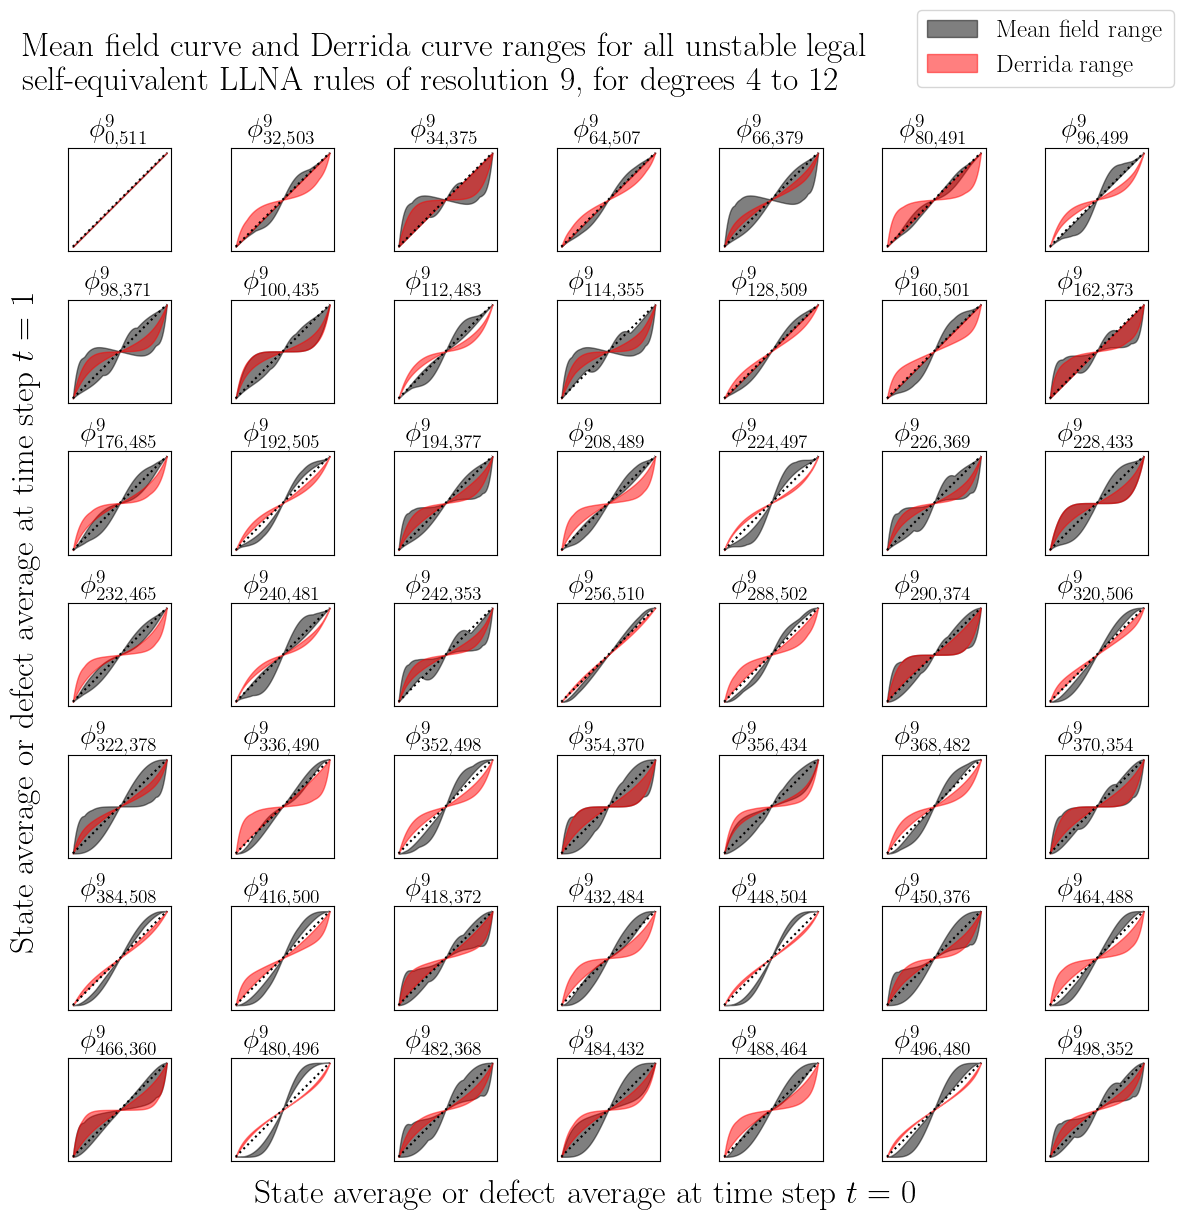

In [102]:
SAVEFIG=True

fig, axs = plt.subplots(7,7,figsize=(12,12))
resolution = 9
degrees = np.linspace(4, 12, 7, dtype=int)

curve_res = 101
rho0_array = np.linspace(0,1,curve_res)
delta0_array = np.linspace(0,1,curve_res)

for row, ax_row in enumerate(axs):
    print(f"Working on row {row} ...")
    for col, ax in tqdm(enumerate(ax_row), total=axs.shape[1]):
        # find rule for this particular ax
        idx = row*7 + col
        beta, sigma = unstable_legal_self_equiv_rule_array[idx]
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        # calculate mean field curves and Derrida curves
        rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])
        delta1_arrays = np.array([derrida_map_analytical(resolution, B_set, S_set, delta0_array, degree) for degree in degrees])
        rho1_arrays_minima = np.min(rho1_arrays, axis=0)
        rho1_arrays_maxima = np.max(rho1_arrays, axis=0)
        delta1_arrays_minima = np.min(delta1_arrays, axis=0)
        delta1_arrays_maxima = np.max(delta1_arrays, axis=0)
        # make plot
        ax.fill_between(rho0_array, rho1_arrays_minima, rho1_arrays_maxima, color='black', alpha=0.5, label="Mean field curve range")
        ax.fill_between(delta0_array, delta1_arrays_minima, delta1_arrays_maxima, color='red', alpha=0.5, label="Derrida curve range")
        ax.plot([0,1], [0,1], 'k:')
        ax.set_title(f"$\\phi^{resolution}_{{{beta},{sigma}}}$", fontsize=20)
        # make plots nicer
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-0.05, 1.05])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect(1)

fontsize=24
fig.supxlabel(f"State average or defect average at time step $t=0$", fontsize=fontsize)
fig.supylabel(f"State average or defect average at time step $t=1$", fontsize=fontsize)
fig.suptitle(f"Mean field curve and Derrida curve ranges for all unstable legal\nself-equivalent LLNA rules of resolution {resolution}, for degrees {degrees[0]} to {degrees[-1]}", fontsize=fontsize, x=0.03, y=0.99, ha='left')
fig.legend(['Mean field range', 'Derrida range'], loc='upper right', bbox_to_anchor=(1,1.02), ncol=1, fontsize=18)
fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"mean-field-and-derrida-ranges-for-all-res{resolution}-unstable-legal-self-equiv-llnas_degree{degrees[0]}-to-{degrees[-1]}.pdf")

## mean field slope and Derrida coefficient in function of density

Interpretation of the mean field slope: the further away from 1, the faster it will want to move. If it's right on the value 1, it won't move much any time soon. If it's a lot above 1, it will want to move out of equilibrium fast. If it's a lot below 1, it will move towards equilibrium fast. Not sure whether this is very useful.

The Derrida coefficient is more interesting, I think, because this tells you whether the system would become even more sensitive to changes when it goes out of equilibrium. If it becomes less sensitive, the system is "shaken up" less, and it could freeze, especially for lattice networks. If it becomes more sensitive, it will shake up en quickly choose a side.

Working on row 0 ...


100%|██████████| 7/7 [00:09<00:00,  1.39s/it]


Working on row 1 ...


100%|██████████| 7/7 [00:09<00:00,  1.41s/it]


Working on row 2 ...


...

100%|██████████| 7/7 [00:09<00:00,  1.39s/it]


Working on row 5 ...


100%|██████████| 7/7 [00:10<00:00,  1.44s/it]


Working on row 6 ...


100%|██████████| 7/7 [00:10<00:00,  1.44s/it]


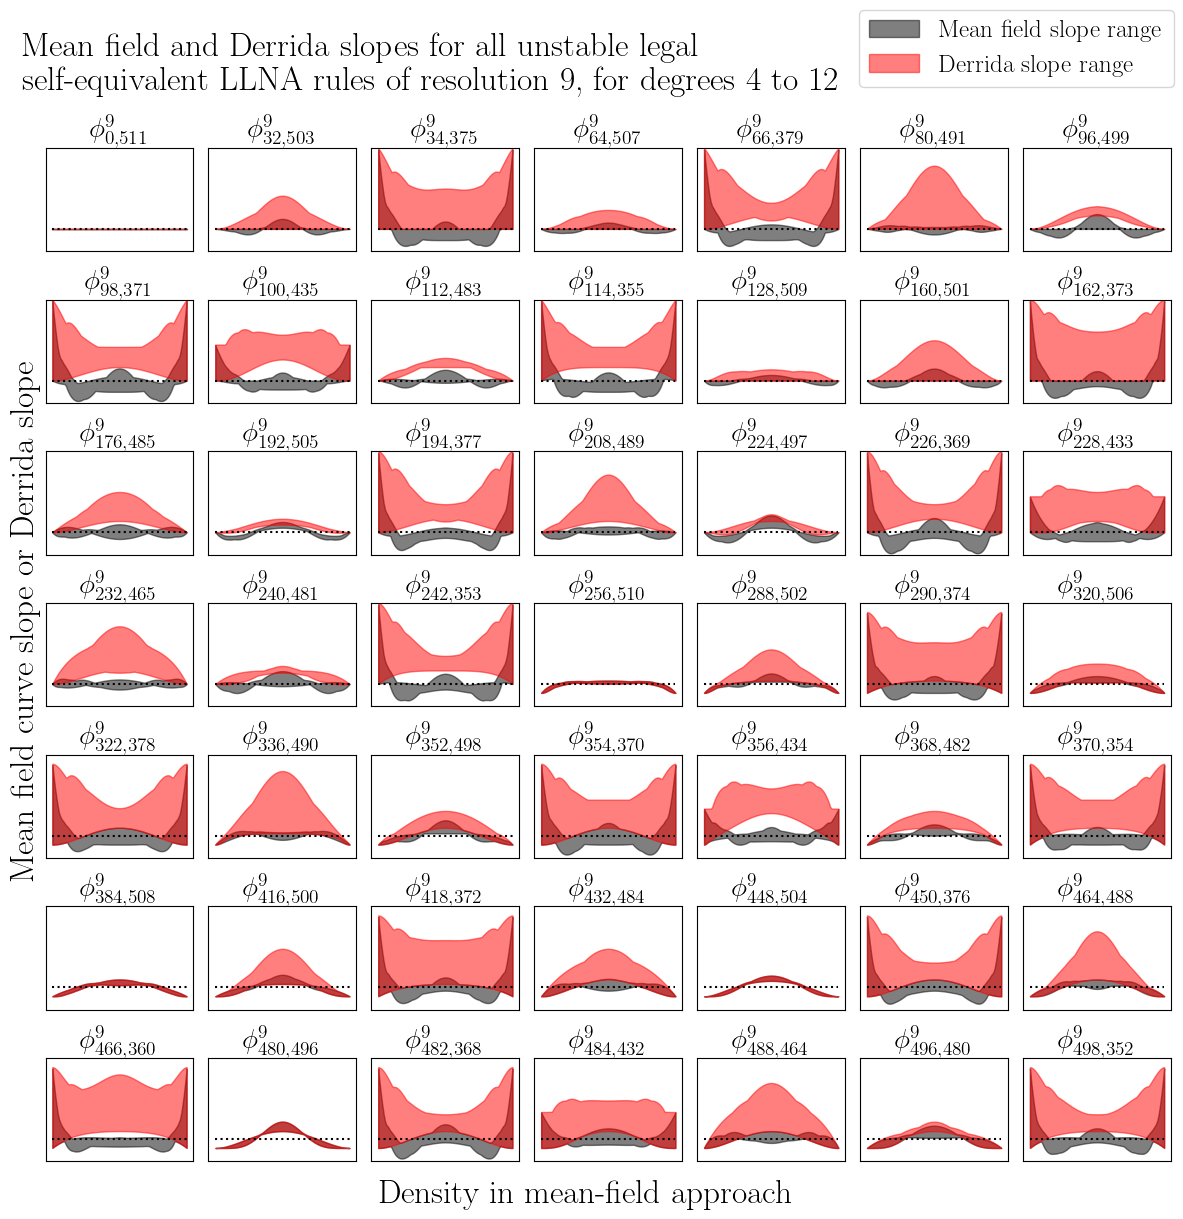

In [32]:
SAVEFIG=True

fig, axs = plt.subplots(7,7,figsize=(12,12))
resolution = 9
degrees = np.linspace(4, 12, 7, dtype=int)

unstable_legal_self_equiv_rule_array = np.array(unstable_legal_self_equiv_rule_list)

curve_res = 101
rho_array = np.linspace(0.001,0.999,curve_res)

for row, ax_row in enumerate(axs):
    print(f"Working on row {row} ...")
    for col, ax in tqdm(enumerate(ax_row), total=axs.shape[1]):
        # find rule for this particular ax
        idx = row*7 + col
        beta, sigma = unstable_legal_self_equiv_rule_array[idx]
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        # calculate mean field curves and Derrida curves
        mf_slopes = np.array([[mean_field_slope(resolution, B_set, S_set, degree, rho_star=rho) for rho in rho_array] for degree in degrees])
        dc_slopes = np.array([[boolean_sens(resolution, B_set, S_set, degree, current_dens=rho) for rho in rho_array] for degree in degrees])
        # find maxima and minima
        mf_slopes_minima = np.min(mf_slopes, axis=0)
        mf_slopes_maxima = np.max(mf_slopes, axis=0)
        dc_slopes_minima = np.min(dc_slopes, axis=0)
        dc_slopes_maxima = np.max(dc_slopes, axis=0)
        # make plot
        ax.fill_between(rho_array, mf_slopes_minima, mf_slopes_maxima, color='black', alpha=0.5)
        ax.fill_between(rho_array, dc_slopes_minima, dc_slopes_maxima, color='red', alpha=0.5)
        ax.plot([0,1], [1,1], 'k:')
        ax.set_title(f"$\\phi^{resolution}_{{{beta},{sigma}}}$", fontsize=20)
        # make plots nicer
        ax.set_xlim([-0.05, 1.05])
        ax.set_ylim([-1.5, 10])
        ax.set_xticks([])
        ax.set_yticks([])

fontsize=24
fig.supxlabel(f"Density in mean-field approach", fontsize=fontsize)
fig.supylabel(f"Mean field curve slope or Derrida slope", fontsize=fontsize)
fig.suptitle(f"Mean field and Derrida slopes for all unstable legal\nself-equivalent LLNA rules of resolution {resolution}, for degrees ${degrees[0]}$ to ${degrees[-1]}$", fontsize=fontsize, x=0.03, y=0.99, ha='left')
fig.legend(['Mean field slope range', 'Derrida slope range'], loc='upper right', bbox_to_anchor=(1,1.02), ncol=1, fontsize=18)
fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"mean-field-and-derrida-slopes-for-all-res{resolution}-unstable-legal-self-equiv-llnas_degree{degrees[0]}-to-{degrees[-1]}.pdf")

It is not entirely clear what should be derived from these plots. But we see for example that $\phi^9_{488,464}$ is very good at density classification on small world networks. This could be attributed to the observation that the Boolean sensitivity stays relatively high, while at the same time the mean field slope stays quite close to $1$ most of the time. The mean field slope does not have a very clear interpretation. The BS however represents 'shaking up' the system, which helps it to progress further along the mean field curve.

## Time series and convergence observation

Create the three types of graphs

In [33]:
# Parameters
width = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

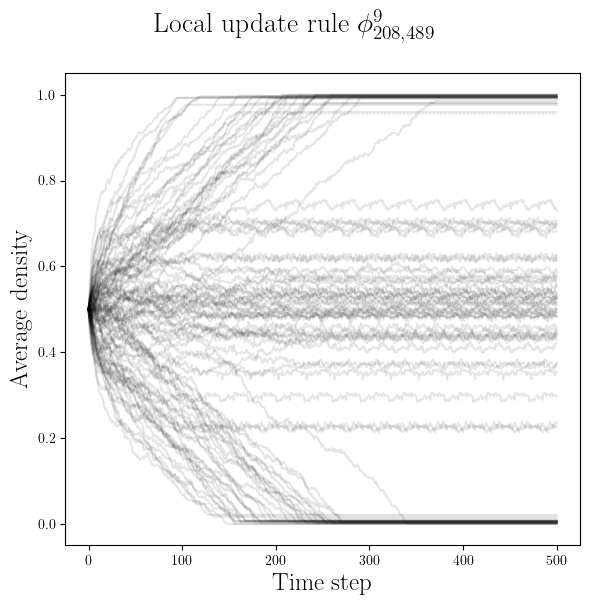

In [34]:
# make simple totalistic CA with radius 2
resolution = 9
beta = 208
sigma = 489
# beta, sigma = life_like_dict["anneal"]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
# model = LLNA(resolution, iso=True)
T = 500

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

num_config = 100
init_dens = 0.5

dens_list_per_graph = []

fig, ax = plt.subplots(1, 1, figsize=(6,6))
fontsize=18
alpha_factor = 0.1

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
# run simulation over a number of time steps on the lattice topology
configs = model.forward(lattice_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
# calculate the means over all nodes
means_over_nodes = np.mean(configs, axis=2).T

# plot
ax.plot(means_over_nodes, alpha=alpha_factor*100/num_config, color='k')
# plot information
ax.set_xlabel("Time step", fontsize=fontsize)
ax.set_ylabel("Average density", fontsize=fontsize)
ax.set_ylim([-0.05, 1.05])

# axs[-1].legend(fontsize=fontsize-4, loc='lower right', ncol=3)

# Add a single legend for all subplots
# handles, labels = axs[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper right', ncol=len(init_dens_list), fontsize=fontsize-2, bbox_to_anchor=(1, 1.04) )

fig.suptitle(f"Local update rule {model.__str__(latex=True)}", fontsize=fontsize+2, y=1)
fig.tight_layout()

Working on row 0 ...


100%|██████████| 7/7 [00:54<00:00,  7.79s/it]


Working on row 1 ...


100%|██████████| 7/7 [00:56<00:00,  8.13s/it]


Working on row 2 ...


...

100%|██████████| 7/7 [00:59<00:00,  8.53s/it]


Working on row 5 ...


100%|██████████| 7/7 [01:00<00:00,  8.65s/it]


Working on row 6 ...


100%|██████████| 7/7 [01:01<00:00,  8.84s/it]


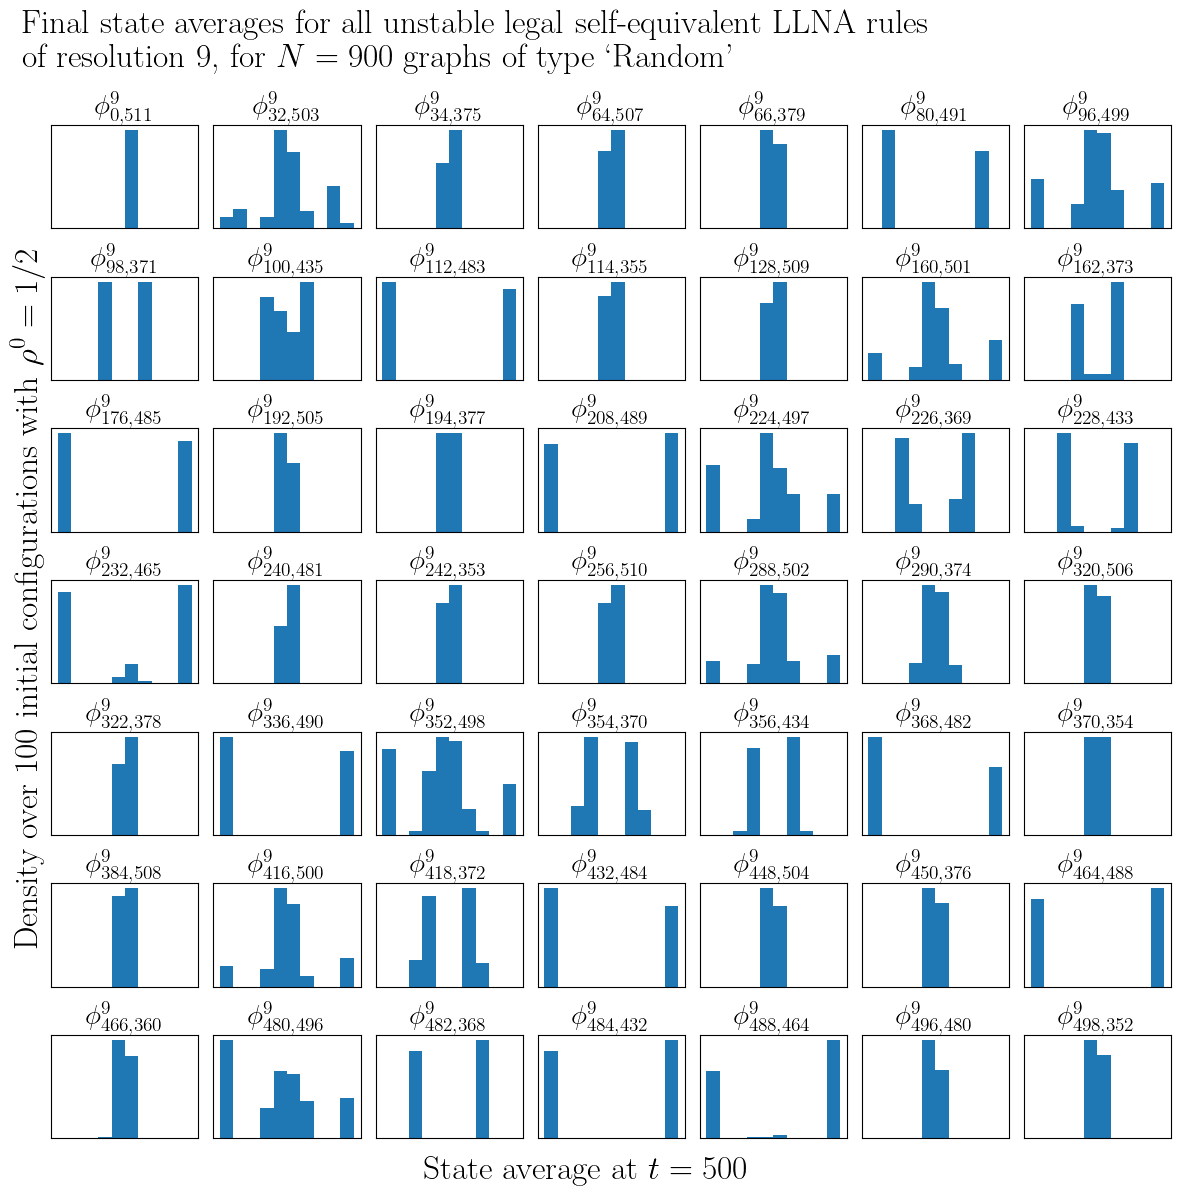

In [104]:
SAVEFIG=True

fig, axs = plt.subplots(7,7,figsize=(12,12))

resolution = 9
degree = 8
bins = np.linspace(0,1,11)
T = 500
num_config = 100

# idx {0:lattice, 1:smallworld, 2:random}
graph_idx = 2
edge = edges[graph_idx]
graph = graphs[graph_idx]
graph_name = graph_names[graph_idx]

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

for row, ax_row in enumerate(axs):
    print(f"Working on row {row} ...")
    for col, ax in tqdm(enumerate(ax_row), total=axs.shape[1]):
        # find rule for this particular ax
        idx = row*7 + col
        beta, sigma = unstable_legal_self_equiv_rule_array[idx]
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        model = LLNA(resolution, B_set, S_set, iso=True)
        # make initial configuration
        init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
        # run simulation over a number of time steps on the lattice topology
        configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
        # calculate the means over all nodes
        means_over_nodes = np.mean(configs, axis=2).T
        # make histograms
        ax.hist(means_over_nodes[-1], bins=bins, density=True)
        ax.set_title(f"$\\phi^{resolution}_{{{beta},{sigma}}}$", fontsize=20)
        # make plots nicer
        ax.set_xlim([-0.05, 1.05])
        # ax.set_ylim([-0.05, 1.05])
        ax.set_xticks([])
        ax.set_yticks([])
        # ax.set_aspect(1)

fontsize=24
fig.supxlabel(f"State average at $t={T}$", fontsize=fontsize)
fig.supylabel(f"Density over {num_config} initial configurations with $\\rho^0=1/2$", fontsize=fontsize)
fig.suptitle(f"Final state averages for all unstable legal self-equivalent LLNA rules\nof resolution {resolution}, for $N={num_nodes}$ graphs of type `{graph_name}'", fontsize=fontsize, x=0.03, y=0.99, ha='left')
fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"finale-state-averages-for-all-res{resolution}-unstable-legal-self-equiv-llnas_random.pdf")

## Inspect some typical behaviour in a video

IMPORTANT! The time until extinction is highly dependent on the size of the network. So there are resonances in the system! These were also clear for ECAs. It's important to keep that in mind! Perhaps we can study this in more detail (or search for the literature), cause it feels like this is an artificial effect of the system.

In [92]:
# Parameters
width = 100                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges) # watts_strogatz_rewire(lattice_graph, 1.)

# find edges
lattice_graph.to_directed()
lattice_edges = tc.tensor(lattice_graph.get_edgelist()).T
lattice_graph.to_undirected()

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

random_graph.to_directed()
random_edges = tc.tensor(random_graph.get_edgelist()).T
random_graph.to_undirected()

# save graphs and edges in list
graphs = [lattice_graph, small_world_graph, random_graph]
graph_names = ["Lattice", f"Small World ($p={rewiring_prob}$)", "Random"]
edges = [lattice_edges, small_world_edges, random_edges]

(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{208,489}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

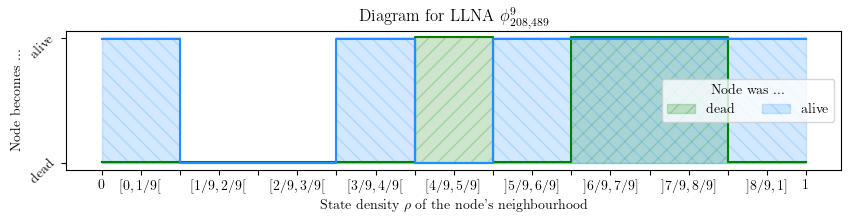

In [166]:
beta, sigma = (208, 489) # life_like_dict["anneal"] # (488, 464) # (226, 369) # (232, 465) # candidate_rules[1]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

In [172]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 100
init_dens = 0.5

init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
# init_defects = np.array([init_config_with_dens(L*L, 1/L/L) for _ in range(num_config)])
# init_configs_defect = (init_configs + init_defects) % 2
# run simulation over a number of time steps
configs = model.forward(random_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
# configs_defect = model.forward(lattice_edges, tc.tensor(init_configs_defect), T=T).numpy().astype(int)
# defects = (configs + configs_defect) % 2

# put back in L x L shape 
configs = configs.reshape((num_config, T+1, width, width))
# defects = defects.reshape((num_config, T+1, L, L))

(array([51.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 49.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

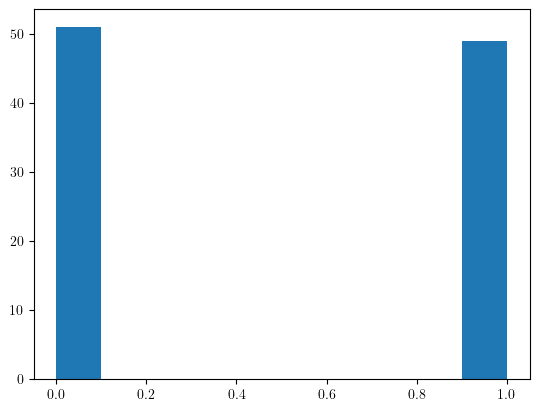

In [173]:
plt.hist(np.mean(configs, axis=(2,3))[:,-1], bins=np.linspace(0,1,11))

In [175]:
candidate_rules

array([[ 80, 491],
       [208, 489],
       [232, 465],
       [336, 490],
       [464, 488],
       [466, 360],
       [488, 464]])

In [87]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [174]:
# show an animation. small world blijft krioelen voor day&night! random ook.
# threshold model wordt heel saai voor small world en voor random network, dus er is wel degelijk iets te zeggen voor het annealed model

graph_name = graph_names[0]
example_idx = 1 # np.random.randint(num_config)
ani = make_animation_object(configs[example_idx], title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [331]:
# save some GIFs for future reference

SAVEGIFS = True
life_like_name = 'max_bs'

if SAVEGIFS:
    for i, config in tqdm(enumerate(configs), total=configs.shape[0]):
        savename = f"animation_llca_{life_like_name}_{width}x{width}_T{T}_sample{i}.gif"

        # example_idx = np.random.randint(num_config)
        ani = make_animation_object(config, title=f"{model.__str__(latex=True)} on graph `{graph_name}'")
        # ani = make_animation_object(defects[example_idx])

        # Save animations as GIFs
        loc = '../figures/gifs/'
        ani.save(loc+savename, writer='pillow', fps=24)  # Using Pillow

        # show inline
        # HTML(ani.to_jshtml())

100%|██████████| 10/10 [07:46<00:00, 46.61s/it]
